# Amazon Customer Sales — Exploratory Data Analysis

## Introduction

This project explores Amazon customer and order data to understand sales performance, customer purchasing behavior, product and brand performance, geographic trends, payment preferences, and order outcomes.

The analysis uses Python and Pandas for data manipulation and exploratory analysis, with Matplotlib and Seaborn used to visualize important patterns and comparisons.

The goal of this analysis is not only to calculate descriptive statistics, but also to identify patterns that could support business decisions around:

* Product and category performance
* Brand performance and customer demand
* Customer purchasing behavior and lifetime value
* Geographic sales concentration
* Payment-method preferences
* Order cancellations and delivery performance

## Business Questions

The analysis is structured around the following questions:

1. Which product categories generate the most revenue, orders, and quantity?
2. Which categories have the highest average order value and discounts?
3. Which brands perform best in terms of revenue, orders, and quantity?
4. How does pricing and discounting vary across brands?
5. How many customers are represented in the dataset, and how frequently do they purchase?
6. Which customers generate the highest lifetime revenue?
7. Which countries, states, and cities contribute the most revenue and customers?
8. Which payment methods are most popular and generate the most revenue?
9. How does average order value differ across payment methods?
10. What proportion of orders are cancelled or delivered?
11. Which categories, countries, and sellers have higher cancellation rates?

## Analysis Structure

The analysis is divided into six major areas:

1. **Category Analysis**
2. **Brand Analysis**
3. **Customer Analysis**
4. **Geographic Analysis**
5. **Payment Method Analysis**
6. **Order Status Analysis**

The objective is to move from descriptive statistics to actionable business insights and provide a clear view of the factors influencing sales and customer activity.


## Analysis Roadmap

| # | Analysis Area               | Key Focus                                            |
| - | --------------------------- | ---------------------------------------------------- |
| 1 | **Category Analysis**       | Revenue, orders, quantity, AOV, discounts            |
| 2 | **Brand Analysis**          | Revenue, orders, quantity, price, discounts          |
| 3 | **Customer Analysis**       | Customers, orders, revenue, quantity, lifetime value |
| 4 | **Geographic Analysis**     | Country, state, and city performance                 |
| 5 | **Payment Method Analysis** | Usage, revenue, and AOV                              |
| 6 | **Order Status Analysis**   | Cancellation and delivery performance                |

### Key Objectives

* Identify the strongest-performing product categories and brands.
* Understand customer purchasing frequency and value.
* Identify the most important geographic markets.
* Evaluate payment-method preferences and their relationship with order value.
* Identify potential cancellation hotspots by category, country, and seller.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Amazon_cleaned.csv")

In [3]:
df_copy = df.copy()

In [4]:
df_copy.head(5)

,OrderID,OrderDate,OrderYear,OrderMonth,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,...,GrossAmount,DiscountedAmount,NetAmount,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,2023,January,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,...,319.77,0.00,319.77,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,2023,December,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,...,251.37,12.57,238.80,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,2022,May,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,...,105.09,10.51,94.58,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,2023,July,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,...,167.90,25.18,142.72,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,2023,February,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,...,1031.28,257.82,773.46,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


# 1. Category Analysis

## 1.1 Revenue by Category

## 1.2 Orders by Category

## 1.3 Quantity by Category

## 1.4 Average Order Value by Category

## 1.5 Average Discount by Category

##### 1.1 Revenue by category

In [46]:
category_revenue = df_copy.groupby("Category")["TotalAmount"].sum().nlargest()
print("Revenue by category =",category_revenue)

Revenue by category = Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Name: TotalAmount, dtype: float64


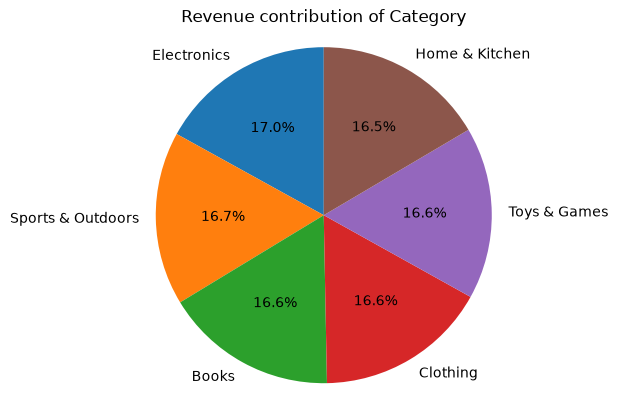

In [6]:
category_revenue = df_copy.groupby("Category")["TotalAmount"].sum()
Top_category_rev = df_copy.groupby("Category")["TotalAmount"].sum().nlargest(10)
category_revenue_contribution = (category_revenue/category_revenue.sum()*100).round(2).sort_values(ascending=False).nlargest(10)
plt.Figure(figsize=(10,8))
plt.pie(Top_category_rev,labels=Top_category_rev.index,autopct="%1.1f%%",startangle=90)
plt.title("Revenue contribution of Category")
plt.axis("equal")
plt.show()

##### 1.2 Orders by Category

In [7]:
category_orders = df_copy.groupby("Category")["OrderID"].nunique().sort_values(ascending=False)
print("Orders by category =",category_orders)

Orders by category = Category
Electronics          16853
Sports & Outdoors    16804
Books                16752
Home & Kitchen       16610
Toys & Games         16542
Clothing             16439
Name: OrderID, dtype: int64


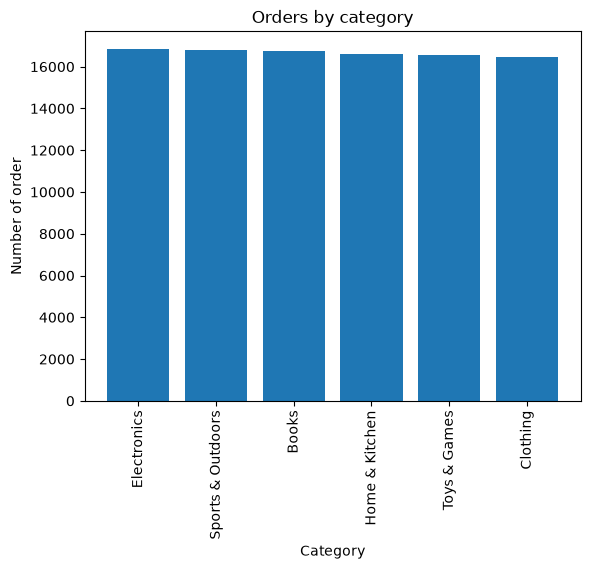

In [8]:
category_orders = df_copy.groupby("Category")["OrderID"].nunique().sort_values(ascending=False)
plt.Figure(figsize=(8,5))
plt.bar(category_orders.index,category_orders.values)
plt.xlabel("Category")
plt.ylabel("Number of order")
plt.xticks(rotation =90)
plt.title("Orders by category")
plt.show()

##### 1.3 Quantity by Category

In [9]:
category_quantity = df_copy.groupby("Category")["Quantity"].sum()
print("Quantity by category =",category_quantity)

Quantity by category = Category
Books                49981
Clothing             49523
Electronics          50696
Home & Kitchen       49624
Sports & Outdoors    50543
Toys & Games         49773
Name: Quantity, dtype: int64


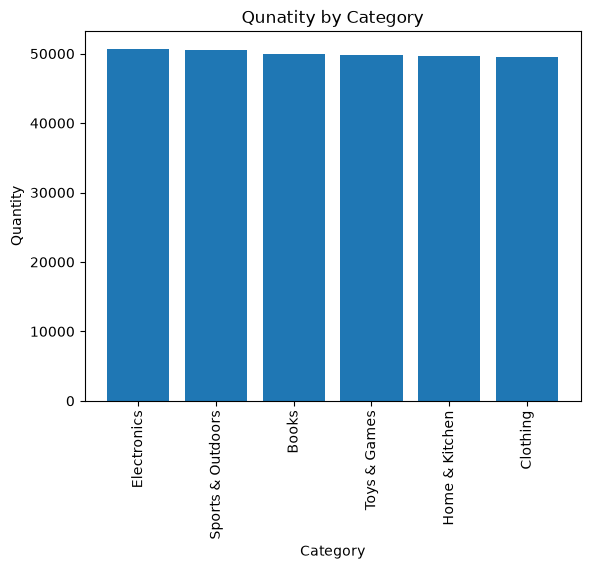

In [10]:
category_quantity = df_copy.groupby("Category")["Quantity"].sum().sort_values(ascending=False)
plt.Figure(figsize=(8,5))
plt.bar(category_quantity.index,category_quantity.values)
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.xticks(rotation =90)
plt.title("Qunatity by Category")
plt.show()

##### 1.4 Average ordervalue by Category

In [11]:
aov = (df_copy.groupby("Category").
       agg(revenue = ("TotalAmount","sum"), orders = ("OrderID","nunique"))
       )
aov["Average order value"] = aov["revenue"] / aov["orders"]
print("Average order value by category =",aov)

Average order value by category =                        revenue  orders  Average order value
Category                                                   
Books              15261837.01   16752           911.045667
Clothing           15253397.50   16439           927.878673
Electronics        15584217.18   16853           924.714720
Home & Kitchen     15163939.36   16610           912.940359
Sports & Outdoors  15345571.88   16804           913.209467
Toys & Games       15216684.99   16542           919.881815


##### 1.5 Average discount by category

In [12]:
average_discount_category = (df_copy.groupby("Category")["Discount"]
                            .mean().sort_values(ascending=False)
                             ).round(2)
average_discount_category

Category
Home & Kitchen       0.08
Electronics          0.07
Toys & Games         0.07
Sports & Outdoors    0.07
Clothing             0.07
Books                0.07
Name: Discount, dtype: float64

### Key Insight

**Electronics generated the highest total revenue among all categories, at approximately 15.58M.**

However, category revenue is relatively balanced overall, with all six categories contributing a similar level of revenue. This suggests that the business is not heavily dependent on a single product category.

# 2. Brand Analysis

## 2.1 Top Brands by Revenue

## 2.2 Top Brands by Quantity

## 2.3 Top Brands by Orders

## 2.4 Average Price by Brand

## 2.5 Average Discount by Brand

##### 2.1 Top brand by revenue

In [13]:
brand_revenue = df_copy.groupby("Brand")["TotalAmount"].sum().nlargest(10)
print("Top brands by revenue =",brand_revenue)

Top brands by revenue = Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64


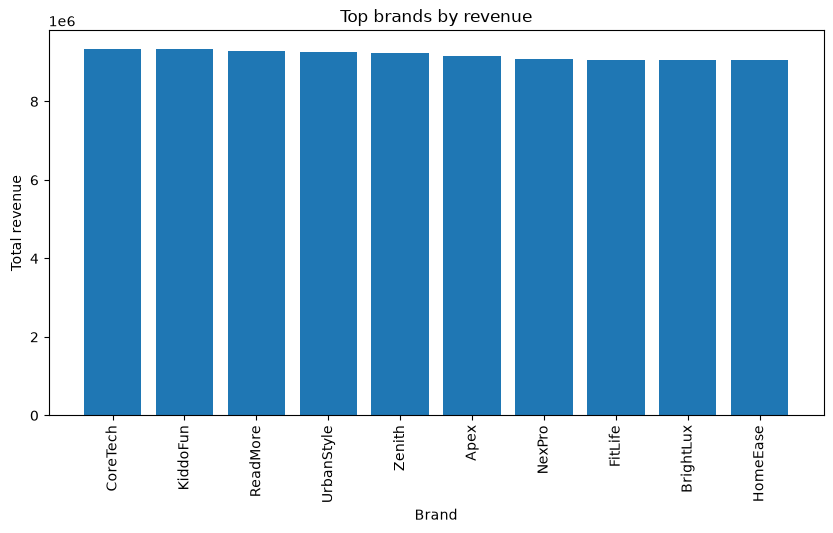

In [14]:
brand_revenue = df_copy.groupby("Brand")["TotalAmount"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(brand_revenue.index,brand_revenue.values)
plt.xlabel("Brand")
plt.ylabel("Total revenue")
plt.title("Top brands by revenue")
plt.xticks(rotation=90)
plt.show()

##### 2.2 Top brands by quantity

In [15]:
brand_quantity = df_copy.groupby("Brand")["Quantity"].sum().nlargest(10)
print("Top brands by quantity =",brand_quantity)

Top brands by quantity = Brand
CoreTech      30430
ReadMore      30421
KiddoFun      30168
FitLife       30121
UrbanStyle    30104
Zenith        30058
Apex          29955
NexPro        29791
BrightLux     29616
HomeEase      29476
Name: Quantity, dtype: int64


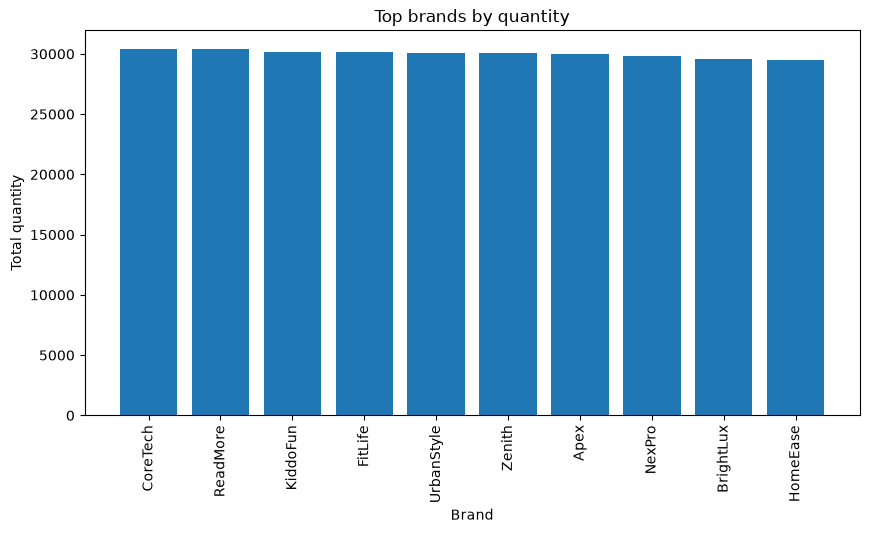

In [16]:
brand_quantity = df_copy.groupby("Brand")["Quantity"].sum().nlargest(10)
plt.figure(figsize=(10,5))
plt.bar(brand_quantity.index,brand_quantity.values)
plt.xlabel("Brand")
plt.ylabel("Total quantity")
plt.title("Top brands by quantity")
plt.xticks(rotation=90)
plt.show()

##### 2.3 Top brands by orders

In [17]:
brand_orders = df_copy.groupby("Brand")["OrderID"].nunique().sort_values(ascending=False)
print("Top brands by orders =",brand_orders)

Top brands by orders = Brand
ReadMore      10204
FitLife       10147
CoreTech      10127
KiddoFun      10077
Zenith         9990
NexPro         9962
Apex           9937
BrightLux      9907
UrbanStyle     9854
HomeEase       9795
Name: OrderID, dtype: int64


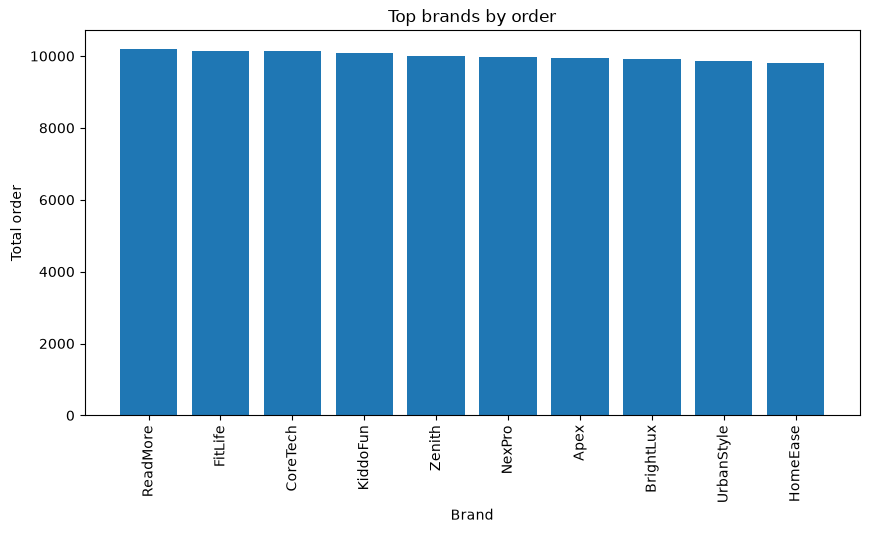

In [18]:
brand_orders = df_copy.groupby("Brand")["OrderID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(brand_orders.index,brand_orders.values)
plt.xlabel("Brand")
plt.ylabel("Total order")
plt.title("Top brands by order")
plt.xticks(rotation=90)
plt.show()

##### 2.4 Average price by brands

In [19]:
avg_price_brand = (df_copy.groupby("Brand")["UnitPrice"].mean()).round(2)
print("Average price by brands =",avg_price_brand)

Average price by brands = Brand
Apex          302.64
BrightLux     303.49
CoreTech      302.66
FitLife       299.43
HomeEase      304.39
KiddoFun      302.93
NexPro        302.16
ReadMore      301.70
UrbanStyle    304.78
Zenith        305.00
Name: UnitPrice, dtype: float64


##### 2.5 Average discount by brands

In [20]:
avg_discount_brand = (df_copy.groupby("Brand")["Discount"].mean()).round(2)
print("Average discount by brand =",avg_discount_brand)

Average discount by brand = Brand
Apex          0.07
BrightLux     0.07
CoreTech      0.07
FitLife       0.08
HomeEase      0.07
KiddoFun      0.07
NexPro        0.07
ReadMore      0.07
UrbanStyle    0.08
Zenith        0.07
Name: Discount, dtype: float64


### Key Insights

- **CoreTech** generated the highest revenue and sold the highest total quantity among the analyzed brands.
- **ReadMore** recorded the highest number of orders.
- The leading brands are relatively close in overall performance, indicating a competitive brand landscape.
- Average brand prices are also closely distributed, suggesting that major differences in revenue are not primarily explained by large differences in average selling price.

# 3. Customer Analysis

## 3.1 Total Customers

## 3.2 Orders per Customer

## 3.3 Revenue per Customer

## 3.4 Average Order Value

## 3.5 Total Quantity Purchased

## 3.6 Customer Lifetime Value

##### 3.1 Total customers

In [21]:
total_customers = df_copy["CustomerID"].nunique()
print("Total number of customer =",total_customers)

Total number of customer = 43233


##### 3.2 Orders per customers

In [22]:
orders_customers = df_copy.groupby("CustomerID")["OrderID"].count().nlargest(10)
print("Orders by customers =",orders_customers)

Orders by customers = CustomerID
CUST023748    10
CUST037103    10
CUST001153     9
CUST003244     9
CUST005654     9
CUST009614     9
CUST012611     9
CUST029921     9
CUST029942     9
CUST031337     9
Name: OrderID, dtype: int64


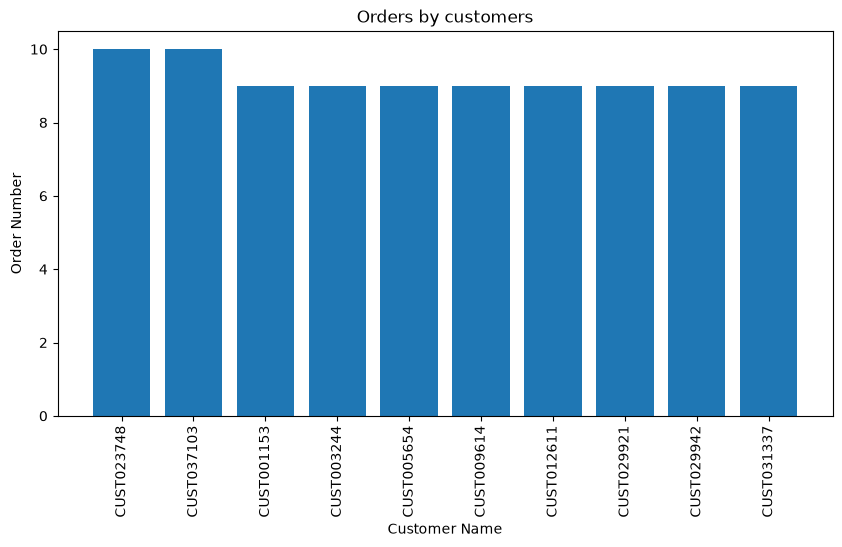

In [23]:
orders_customers = df_copy.groupby("CustomerID")["OrderID"].count().nlargest(10)
plt.figure(figsize=(10,5))
plt.bar(orders_customers.index,orders_customers.values)
plt.xlabel("Customer Name")
plt.ylabel("Order Number")
plt.title("Orders by customers")
plt.xticks(rotation=90)
plt.show()

##### 3.3 Revenue per customer

In [24]:
revenue_customer = df_copy.groupby("CustomerID")["TotalAmount"].sum().nlargest(10)
print("Lifetime Revenue by top 10 customers =",revenue_customer)

Lifetime Revenue by top 10 customers = CustomerID
CUST023748    15215.79
CUST009614    12160.96
CUST034178    11418.88
CUST001153    11282.96
CUST004883    11214.44
CUST000787    10962.32
CUST015677    10956.10
CUST042689    10726.80
CUST015231    10638.79
CUST033270    10593.41
Name: TotalAmount, dtype: float64


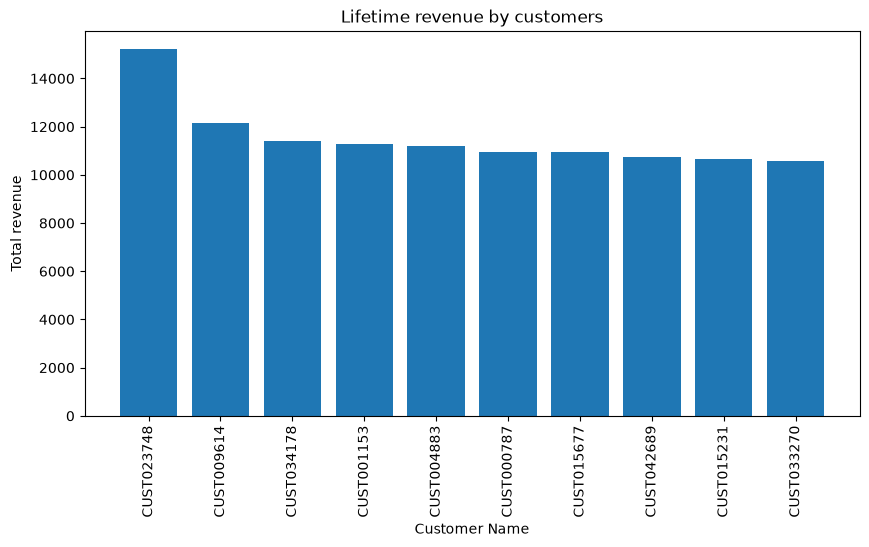

In [25]:
revenue_customer = df_copy.groupby("CustomerID")["TotalAmount"].sum().nlargest(10)
plt.figure(figsize=(10,5))
plt.bar(revenue_customer.index,revenue_customer.values)
plt.xlabel("Customer Name")
plt.ylabel("Total revenue")
plt.title("Lifetime revenue by customers")
plt.xticks(rotation=90)
plt.show()

##### 3.5 Average order value

In [26]:
average_order_value = ((df_copy.groupby("CustomerID")["TotalAmount"].sum()/
                        df_copy.groupby("CustomerID")["OrderID"].nunique()).round(2)
                       ).sort_values(ascending=False)
print("Average order value =",average_order_value)

Average order value = CustomerID
CUST010791    3484.44
CUST030934    3439.11
CUST021621    3385.69
CUST012476    3366.38
CUST014210    3344.38
               ...   
CUST007806       9.43
CUST041469       7.65
CUST011470       7.05
CUST031790       6.57
CUST017538       6.19
Length: 43233, dtype: float64


##### 3.6 Total quantity purchased

In [27]:
quantity_purchase = df_copy.groupby("CustomerID")["Quantity"].sum().sort_values(ascending=False)
print("Total quantity purchase =",quantity_purchase)

Total quantity purchase = CustomerID
CUST029942    35
CUST048737    33
CUST023748    33
CUST043080    32
CUST042938    30
              ..
CUST043025     1
CUST043022     1
CUST043046     1
CUST043044     1
CUST008240     1
Name: Quantity, Length: 43233, dtype: int64


##### 3.7 Customer lifetime value

In [28]:
df_copy["OrderDate"] = pd.to_datetime(df_copy["OrderDate"])
average_order_value = ((df_copy.groupby("CustomerID")["TotalAmount"].sum()/
                        df_copy.groupby("CustomerID")["OrderID"].nunique()).round(2))
pruchase_frequency = (df_copy["OrderID"].nunique()/df_copy["CustomerID"].nunique())
customer_lifespan = df_copy.groupby("CustomerID")["OrderDate"].agg(lambda x : (x.max()-x.min()).days).mean() / 365
customer_lifetime_value = ((average_order_value*pruchase_frequency*customer_lifespan).round(2)).sort_values(ascending=False)
print("Customer lifetime value =",customer_lifetime_value)

Customer lifetime value = CustomerID
CUST010791    12590.86
CUST030934    12427.06
CUST021621    12234.03
CUST012476    12164.25
CUST014210    12084.76
                ...   
CUST007806       34.07
CUST041469       27.64
CUST011470       25.47
CUST031790       23.74
CUST017538       22.37
Length: 43233, dtype: float64


### Key Insights

- The dataset contains **43,233 customers**.
- Most customers have relatively low order frequency, while a smaller group of customers places substantially more orders.
- Customer value is highly variable, with a small group contributing significantly higher lifetime revenue.
- These high-value customers represent an important segment for retention and loyalty strategies.

# 4. Geographic Analysis

## 4.1 Country Analysis

### 4.1.1 Revenue by Country

### 4.1.2 Orders by Country

### 4.1.3 Customers by Country

## 4.2 State Analysis

### 4.2.1 Revenue by State

### 4.2.2 Customers by State

### 4.2.3 Average Order Value by State

## 4.3 City Analysis

### 4.3.1 Top Cities by Revenue

### 4.3.2 Highest-Value Cities

##### 4.1.1 Revenue by country

In [29]:
revenue_country = df_copy.groupby("Country")["TotalAmount"].sum().nlargest()
print("Total revenue by country is =",revenue_country)

Total revenue by country is = Country
United States     64310048.50
India             13875839.12
Canada             5323757.00
United Kingdom     4526896.86
Australia          3789106.44
Name: TotalAmount, dtype: float64


##### 4.1.2 Oreder by country

In [30]:
order_country = df_copy.groupby("Country")["OrderID"].nunique().sort_values(ascending=False)
print("Total orders by country =",order_country)

Total orders by country = Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Name: OrderID, dtype: int64


##### 4.1.3 Customer by country

In [31]:
customer_country = df_copy.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False)
print("Total customer from country =",customer_country)

Total customer from country = Country
United States     37731
India             12976
Canada             5486
United Kingdom     4742
Australia          3969
Name: CustomerID, dtype: int64


##### 4.2.1 Top states by revenue

In [32]:
revenue_state = df_copy.groupby("State")["TotalAmount"].sum().nlargest(10)
print("Top state by revenue =",revenue_state)

Top state by revenue = State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
Name: TotalAmount, dtype: float64


##### 4.2.2 Top state by customer

In [33]:
customer_state = df_copy.groupby("State")["CustomerID"].nunique().sort_values(ascending=False)
print("Top state by customer =",customer_state)

Top state by customer = State
TX    19565
CA    16528
FL     4872
NC     4852
IL     4800
DC     4792
WA     4773
OH     4770
PA     4762
CO     4732
IN     4729
AZ     4699
NY     4694
Name: CustomerID, dtype: int64


##### 4.2.3 Average order value by state

In [34]:
average_ordervalue_state = (
    df_copy.groupby("State").
                            agg(total_revenue= ("TotalAmount","sum"),
                                                        total_order= ("OrderID","nunique"))
                            )
average_ordervalue_state["aov"]=(average_ordervalue_state["total_revenue"]/average_ordervalue_state["total_order"])
print("Average order value by state =",average_ordervalue_state.sort_values("aov",ascending=False).round(2))

Average order value by state =        total_revenue  total_order     aov
State                                    
CO        4638498.97         4991  929.37
NC        4747701.73         5110  929.10
PA        4650673.88         5014  927.54
IN        4609048.43         4970  927.37
WA        4660962.17         5039  924.98
IL        4632847.44         5020  922.88
NY        4554358.08         4949  920.26
OH        4615442.32         5021  919.23
TX       22862540.54        24896  918.32
CA       18231196.79        19921  915.17
AZ        4504324.19         4941  911.62
DC        4520876.11         5021  900.39
FL        4597177.27         5107  900.17


##### 4.3.1 Top cities

In [35]:
top_cities= df_copy.groupby("City")["TotalAmount"].sum().nlargest(10)
print("Top cities are =",top_cities)

Top cities are = City
Charlotte       4747701.73
Dallas          4730108.67
San Jose        4669614.33
Seattle         4660962.17
Philadelphia    4650673.88
Denver          4638498.97
Austin          4638403.18
Chicago         4632847.44
Los Angeles     4620629.78
Columbus        4615442.32
Name: TotalAmount, dtype: float64


##### 4.3.2 Highest value cities

In [36]:
highest_value_city = df_copy.groupby("City",as_index=False)["TotalAmount"].sum()
highest_value_city.loc[highest_value_city["TotalAmount"].idxmax()]
print("Highest value city is =",highest_value_city)

Highest value city is =              City  TotalAmount
0          Austin   4638403.18
1       Charlotte   4747701.73
2         Chicago   4632847.44
3        Columbus   4615442.32
4          Dallas   4730108.67
5          Denver   4638498.97
6      Fort Worth   4502058.68
7         Houston   4485649.04
8    Indianapolis   4609048.43
9    Jacksonville   4597177.27
10    Los Angeles   4620629.78
11       New York   4554358.08
12   Philadelphia   4650673.88
13        Phoenix   4504324.19
14    San Antonio   4506320.97
15      San Diego   4428865.07
16  San Francisco   4512087.61
17       San Jose   4669614.33
18        Seattle   4660962.17
19     Washington   4520876.11


### Key Insights

- The **United States is the dominant market**, generating approximately 64.31M in revenue and 70,058 orders.
- India is the second-largest market by both revenue and order volume.
- Within the state-level analysis, **Texas (TX)** generates the highest revenue at approximately 22.86M, followed by California (CA) at approximately 18.23M.
- The geographic distribution indicates that sales are heavily concentrated in the United States, with Texas and California representing particularly important state-level markets.

# 5. Payment Method Analysis

## 5.1 Most Popular Payment Methods

## 5.2 Revenue by Payment Method

## 5.3 Average Order Value by Payment Method

##### 5.1 Most Popular Payment Methods

In [37]:
popular_payment = df_copy["PaymentMethod"].value_counts()
print("Most popular payment methods =",popular_payment)

Most popular payment methods = PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


##### 5.2 Revenue by Payment Method

In [38]:
payment_method_revenue = df_copy.groupby("PaymentMethod")["TotalAmount"].sum().sort_values(ascending=False)
print("Highest revenue generated by payment method =",payment_method_revenue)

Highest revenue generated by payment method = PaymentMethod
Credit Card         32122158.69
Debit Card          18538678.53
UPI                 13896028.55
Amazon Pay          13697498.42
Net Banking          9055674.57
Cash on Delivery     4515609.16
Name: TotalAmount, dtype: float64


##### 5.3 Average ordervalue by Payment method

In [39]:
order_total = df_copy.groupby(["OrderID","PaymentMethod"])["TotalAmount"].sum().reset_index()
average_order_value = (order_total.groupby("PaymentMethod")["TotalAmount"].mean().sort_values(ascending=False)).round(2)
print("Average order value by payment method =",average_order_value)

Average order value by payment method = PaymentMethod
Debit Card          925.82
UPI                 922.34
Credit Card         916.78
Cash on Delivery    916.32
Net Banking         912.23
Amazon Pay          912.13
Name: TotalAmount, dtype: float64


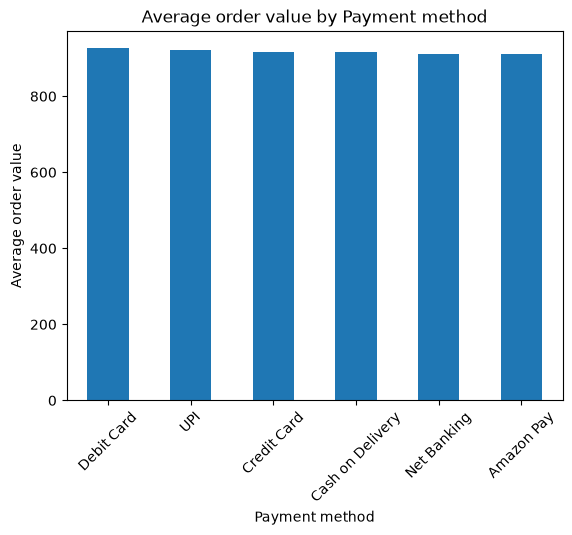

In [40]:
average_order_value.plot(kind="bar")
plt.xlabel("Payment method")
plt.ylabel("Average order value")
plt.title("Average order value by Payment method")
plt.xticks(rotation=45)
plt.show()

### Key Insights

- **Credit Card is the most popular payment method**, with 35,038 orders.
- Credit Card also generates the highest total revenue at approximately 32.12M.
- **Debit Card has the highest average order value**, at approximately 925.82.
- Although payment methods differ substantially in usage and total revenue, their average order values are relatively close.

# 6. Order Status Analysis

## 6.1 Overall Cancellation Rate

## 6.2 Overall Delivery Rate

## 6.3 Cancellation Rate by Category

## 6.4 Cancellation Rate by Country

## 6.5 Cancellation Rate by Seller

##### 6.1 Overall Cancellation Rate

In [41]:
cancellation_rate = (df_copy["OrderStatus"] == "Cancelled").mean()*100
print(f"Cancellation rate: {cancellation_rate:.2f}%")

Cancellation rate: 3.03%


##### 6.2 Overall Delivery Rate

In [42]:
delivery_rate = (df_copy["OrderStatus"] == "Delivered").mean()*100
print(f"Delivery Rate {delivery_rate :.2f}%")

Delivery Rate 74.63%


##### 6.3 Cancellation By Category

In [43]:
cancellation_category = (
    df_copy.groupby("Category")["OrderStatus"]
            .apply(lambda x:(x == "Cancelled").mean()*100)
                .sort_values(ascending=False)
).round(2)
print("Cancellation rate by category =",cancellation_category)

Cancellation rate by category = Category
Electronics          3.23
Toys & Games         3.10
Home & Kitchen       3.06
Books                2.98
Sports & Outdoors    2.96
Clothing             2.84
Name: OrderStatus, dtype: float64


##### 6.4 Cancellation By Country

In [44]:
cancellation_country = (
    df_copy.groupby("Country")["OrderStatus"]
            .apply(lambda x:(x == "Cancelled").mean()*100)
                .sort_values(ascending=False)
).round(2)
print("Cancellation by country =",cancellation_country)

Cancellation by country = Country
Canada            3.20
United Kingdom    3.12
United States     3.03
Australia         2.95
India             2.94
Name: OrderStatus, dtype: float64


##### 6.5 Cancellation By Sellar

In [45]:
cancellation_sellar = (
    df_copy.groupby("SellerID")["OrderStatus"]
            .apply(lambda x:(x == "Cancelled").mean()*100)
                .sort_values(ascending=False)
).round(2).head(20)
print("Cancellation by seller =",cancellation_sellar)

Cancellation by seller = SellerID
SELL00191    14.29
SELL01239    12.77
SELL01062    12.24
SELL01615    12.20
SELL01533    12.00
SELL01979    11.76
SELL01287    11.36
SELL01442    10.94
SELL00722    10.87
SELL00355    10.81
SELL01502    10.71
SELL01472    10.64
SELL00717    10.42
SELL01972    10.42
SELL00170    10.26
SELL00196    10.26
SELL01571    10.20
SELL00462    10.00
SELL01558    10.00
SELL00345    10.00
Name: OrderStatus, dtype: float64


### Key Insights

- The overall cancellation rate is **3.03%**, indicating that most orders are not cancelled.
- **Electronics has the highest cancellation rate among categories at 3.23%**, while Clothing has the lowest at 2.84%.
- Cancellation rates across countries are relatively similar, ranging from 2.94% to 3.20%.
- Seller-level cancellation rates show much greater variation, with some sellers recording cancellation rates above 10%.
- This suggests that seller-level performance may be a more important area for investigation than country-level differences.



# 7. Conclusion

## Overall Findings

This exploratory data analysis provides an overview of customer purchasing behavior, product performance, geographic sales distribution, payment preferences, and order outcomes.

Several important patterns emerged from the analysis:

* **Category performance is relatively balanced**, although Electronics generated the highest total revenue at approximately 15.58M.
* **CoreTech** was the strongest brand by revenue and quantity, while **ReadMore** recorded the highest number of orders.
* The dataset contains **43,233 customers**, with substantial variation in purchasing frequency and customer lifetime value.
* The **United States is the dominant geographic market**, generating approximately 64.31M in revenue and 70,058 orders. Texas and California are the leading states by revenue.
* **Credit Card** is the most widely used payment method and generates the highest total revenue, while **Debit Card** has the highest average order value.
* The overall **cancellation rate is 3.03%**, but seller-level cancellation rates vary considerably, with some sellers exceeding 10%.
* Category and country cancellation rates are comparatively close, suggesting that **seller-level performance may deserve greater attention when investigating cancellation issues**.

## Business Takeaways

Based on these findings, several areas could be explored further:

1. **Strengthen high-performing categories and brands** while maintaining a balanced product portfolio.
2. **Focus retention strategies on high-value customers** to encourage repeat purchases and maximize customer lifetime value.
3. **Prioritize the United States market**, particularly high-performing states such as Texas and California.
4. **Monitor seller-level cancellation performance** and investigate sellers with unusually high cancellation rates.
5. **Continue supporting multiple payment methods**, while recognizing Credit Card as the primary payment channel and Debit Card as the highest-AOV method.

## Final Note

This EDA provides a descriptive view of the Amazon customer and order dataset and highlights areas that warrant deeper investigation. Further analysis could examine **time-based sales trends, customer segmentation, product-level performance, seller performance, and the relationship between discounts, order value, and cancellations** to generate more targeted business recommendations.
